# 1. Imports & setup

This notebook implements a reproducible reimplementation of the 1D-CNN intrusion-detection experiment described by Sharma et al. (2024).

**Important:** this is not the authors' original source code. The paper does not publish enough information to reconstruct the exact implementation. Parameters explicitly reported by the paper are marked `[PAPER]`; missing architectural details are marked `[ASSUMPTION]`.

The notebook is designed for Google Colab. Dataset files can be uploaded directly to Colab or mounted from Google Drive.


In [3]:
# ============================================================
# Imports & reproducibility
# ============================================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Seed:", SEED)


TensorFlow: 2.20.0
NumPy: 2.1.3
Seed: 42


## Colab dataset upload

Your local folders contain:

**NSL-KDD**
- `KDDTrain+`
- `KDDTest+`

**UNSW-NB15**
- `UNSW_NB15_training-set`
- `UNSW_NB15_testing-set`

This notebook uses those four files.

You do **not** need to upload `UNSW-NB15_1` through `UNSW-NB15_4`,
`UNSW-NB15_features`, or `UNSW-NB15_LIST_EVENTS` for this workflow.

The upload cell accepts the files even if Windows hides their extensions
(for example `.csv` or `.txt`).

In [4]:
# ============================================================
# Automatically locate the four required files
# ============================================================

from pathlib import Path

COLAB_ROOT = Path("/content")

def find_uploaded_file(possible_stems):
    candidates = []

    for path in COLAB_ROOT.iterdir():
        if not path.is_file():
            continue

        name_lower = path.name.lower()

        for stem in possible_stems:
            stem_lower = stem.lower()
            if (
                name_lower == stem_lower
                or name_lower.startswith(stem_lower + ".")
            ):
                candidates.append(path)

    for stem in possible_stems:
        for path in candidates:
            if path.name.lower() == stem.lower():
                return str(path)

    if candidates:
        return str(candidates[0])

    raise FileNotFoundError(
        f"Could not find a file matching {possible_stems}. "
        f"Files in /content: {[p.name for p in COLAB_ROOT.iterdir()]}"
    )


NSL_KDD_TRAIN_PATH = find_uploaded_file(["KDDTrain+"])
NSL_KDD_TEST_PATH = find_uploaded_file(["KDDTest+"])

UNSW_TRAIN_PATH = find_uploaded_file([
    "UNSW_NB15_training-set",
    "UNSW-NB15_training-set"
])

UNSW_TEST_PATH = find_uploaded_file([
    "UNSW_NB15_testing-set",
    "UNSW-NB15_testing-set"
])

print("Detected dataset files:")
print("NSL-KDD train :", NSL_KDD_TRAIN_PATH)
print("NSL-KDD test  :", NSL_KDD_TEST_PATH)
print("UNSW train    :", UNSW_TRAIN_PATH)
print("UNSW test     :", UNSW_TEST_PATH)


Detected dataset files:
NSL-KDD train : /content/KDDTrain+.txt
NSL-KDD test  : /content/KDDTest+.txt
UNSW train    : /content/UNSW_NB15_training-set.csv
UNSW test     : /content/UNSW_NB15_testing-set.csv


### Dataset split used by this notebook

Although NSL-KDD and UNSW-NB15 are distributed with predefined
training/testing files, this experiment uses the **60% train /
15% validation / 25% test split requested for this project**.

Therefore the notebook combines each dataset's provided train and
test files first, then performs a fresh stratified 60/15/25 split.

The final test set is therefore **not identical** to the original
KDDTest+ or UNSW testing-set partition.

## Experiment configuration

### Reported by the paper [PAPER]
- Kernel size = 3
- Max-pooling size = 2
- ReLU
- Learning rate = 0.001
- Weight decay = 0.0001
- Epochs = 20
- 5 output classes
- Softmax
- Sparse categorical cross-entropy
- Adam
- Dropout = 0

### Missing from the paper

The complete 1D-CNN filter/layer configuration is not specified.

This notebook uses **64 → 32 → 32** convolutional filters as an `[ASSUMPTION]`, following the progression reported for the paper's 2D-CNN.


In [5]:
# ============================================================
# Experiment configuration
# ============================================================

# [PAPER]
N_CLASSES = 5
KERNEL_SIZE = 3
POOL_SIZE = 2
ACTIVATION = "relu"
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001
EPOCHS = 20
DROPOUT_RATE = 0.0

# [ASSUMPTION]
CONV_FILTERS = [64, 32, 32]

# Requested split
TRAIN_SIZE = 0.60
VAL_SIZE = 0.15
TEST_SIZE = 0.25

# [ASSUMPTION]
# The paper does not provide a batch size in enough detail for exact
# reconstruction, so this notebook uses 128.
BATCH_SIZE = 128

assert abs(TRAIN_SIZE + VAL_SIZE + TEST_SIZE - 1.0) < 1e-9

print("Filters:", CONV_FILTERS)
print("Kernel:", KERNEL_SIZE)
print("Pool:", POOL_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Epochs:", EPOCHS)
print("Batch size [ASSUMPTION]:", BATCH_SIZE)


Filters: [64, 32, 32]
Kernel: 3
Pool: 2
Learning rate: 0.001
Weight decay: 0.0001
Epochs: 20
Batch size [ASSUMPTION]: 128


# 2. Load & preprocess NSL-KDD

Five classes:
- Normal
- DoS
- Probe
- R2L
- U2R

The paper reports removing six highly correlated/redundant features from NSL-KDD.


In [7]:
# ============================================================
# NSL-KDD column definitions
# ============================================================

NSL_KDD_COLUMNS = [
    "duration", "protocol_type", "service", "flag",
    "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
    "hot", "num_failed_logins", "logged_in", "num_compromised",
    "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count",
    "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "class", "difficulty"
]

NSL_LABEL_COLUMN = "class"

NSL_DROP_FEATURES = [
    "srv_serror_rate",
    "dst_host_srv_rerror_rate",
    "num_root",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "srv_rerror_rate"
]

NSL_ATTACK_MAP = {
    "back": "DoS", "land": "DoS", "neptune": "DoS", "pod": "DoS",
    "smurf": "DoS", "teardrop": "DoS", "apache2": "DoS",
    "udpstorm": "DoS", "processtable": "DoS", "mailbomb": "DoS",
    "worm": "DoS",

    "ipsweep": "Probe", "mscan": "Probe", "nmap": "Probe",
    "portsweep": "Probe", "saint": "Probe", "satan": "Probe",

    "ftp_write": "R2L", "guess_passwd": "R2L", "imap": "R2L",
    "multihop": "R2L", "phf": "R2L", "spy": "R2L",
    "warezclient": "R2L", "warezmaster": "R2L", "named": "R2L",
    "sendmail": "R2L", "snmpgetattack": "R2L", "snmpguess": "R2L",
    "xlock": "R2L", "xsnoop": "R2L", "httptunnel": "R2L",

    "buffer_overflow": "U2R", "loadmodule": "U2R", "perl": "U2R",
    "rootkit": "U2R", "sqlattack": "U2R", "xterm": "U2R", "ps": "U2R",
}


In [8]:
# ============================================================
# Load and combine NSL-KDD KDDTrain+ and KDDTest+
# ============================================================

def read_nsl_file(path):
    # KDDTrain+ and KDDTest+ are commonly distributed without headers.
    df = pd.read_csv(path, header=None)

    if df.shape[1] != len(NSL_KDD_COLUMNS):
        # Fall back to a normal CSV with a header.
        df = pd.read_csv(path)

    if df.shape[1] != len(NSL_KDD_COLUMNS):
        raise ValueError(
            f"{path} has {df.shape[1]} columns, but expected "
            f"{len(NSL_KDD_COLUMNS)} NSL-KDD columns."
        )

    df.columns = NSL_KDD_COLUMNS
    return df


nsl_train_raw = read_nsl_file(NSL_KDD_TRAIN_PATH)
nsl_test_raw = read_nsl_file(NSL_KDD_TEST_PATH)

nsl_df = pd.concat(
    [nsl_train_raw, nsl_test_raw],
    ignore_index=True
)

print("KDDTrain+ shape:", nsl_train_raw.shape)
print("KDDTest+ shape :", nsl_test_raw.shape)
print("Combined NSL-KDD shape:", nsl_df.shape)

display(nsl_df.head())


KDDTrain+ shape: (125973, 43)
KDDTest+ shape : (22544, 43)
Combined NSL-KDD shape: (148517, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [9]:
# ============================================================
# Create NSL-KDD five-class target
# ============================================================

nsl_df[NSL_LABEL_COLUMN] = (
    nsl_df[NSL_LABEL_COLUMN]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.rstrip(".")
)

def map_nsl_label(label):
    if label == "normal":
        return "Normal"
    return NSL_ATTACK_MAP.get(label, None)

nsl_df["target"] = nsl_df[NSL_LABEL_COLUMN].apply(map_nsl_label)

unknown_nsl = nsl_df.loc[
    nsl_df["target"].isna(),
    NSL_LABEL_COLUMN
].unique()

if len(unknown_nsl) > 0:
    print("Unmapped labels:", unknown_nsl)
    nsl_df = nsl_df.dropna(subset=["target"]).copy()

print(nsl_df["target"].value_counts())


target
Normal    77054
DoS       53387
Probe     14077
R2L        3880
U2R         119
Name: count, dtype: int64


In [10]:
# ============================================================
# Prepare NSL-KDD
# ============================================================

def prepare_nsl_kdd(df):
    df = df.copy()

    columns_to_drop = [
        NSL_LABEL_COLUMN,
        "target",
        "difficulty"
    ]

    # [PAPER]
    columns_to_drop += [
        col for col in NSL_DROP_FEATURES
        if col in df.columns
    ]

    X = df.drop(columns=list(set(columns_to_drop)), errors="ignore")
    y = df["target"].copy()

    print("Features after paper-reported removals:", X.shape[1])

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=y
    )

    val_fraction = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=val_fraction,
        random_state=SEED,
        stratify=y_temp
    )

    categorical_columns = [
        col for col in X_train.columns
        if X_train[col].dtype == "object"
    ]

    numerical_columns = [
        col for col in X_train.columns
        if col not in categorical_columns
    ]

    encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    X_train_cat = encoder.fit_transform(X_train[categorical_columns])
    X_val_cat = encoder.transform(X_val[categorical_columns])
    X_test_cat = encoder.transform(X_test[categorical_columns])

    def numeric_part(data):
        return (
            data[numerical_columns]
            .apply(pd.to_numeric, errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )

    X_train_num = numeric_part(X_train)
    X_val_num = numeric_part(X_val)
    X_test_num = numeric_part(X_test)

    X_train_processed = np.hstack([X_train_num.values, X_train_cat])
    X_val_processed = np.hstack([X_val_num.values, X_val_cat])
    X_test_processed = np.hstack([X_test_num.values, X_test_cat])

    # [PAPER]
    # Min-Max normalization.
    scaler = MinMaxScaler()
    X_train_processed = scaler.fit_transform(X_train_processed)
    X_val_processed = scaler.transform(X_val_processed)
    X_test_processed = scaler.transform(X_test_processed)

    class_names = ["Normal", "DoS", "Probe", "R2L", "U2R"]
    class_to_id = {name: idx for idx, name in enumerate(class_names)}

    y_train_encoded = y_train.map(class_to_id).astype(np.int64).values
    y_val_encoded = y_val.map(class_to_id).astype(np.int64).values
    y_test_encoded = y_test.map(class_to_id).astype(np.int64).values

    X_train_cnn = X_train_processed[..., np.newaxis]
    X_val_cnn = X_val_processed[..., np.newaxis]
    X_test_cnn = X_test_processed[..., np.newaxis]

    return (
        X_train_cnn, X_val_cnn, X_test_cnn,
        y_train_encoded, y_val_encoded, y_test_encoded,
        scaler, encoder, class_names
    )

(
    X_nsl_train, X_nsl_val, X_nsl_test,
    y_nsl_train, y_nsl_val, y_nsl_test,
    nsl_scaler, nsl_encoder, nsl_class_names
) = prepare_nsl_kdd(nsl_df)

print("Train:", X_nsl_train.shape)
print("Val  :", X_nsl_val.shape)
print("Test :", X_nsl_test.shape)


Features after paper-reported removals: 35
Train: (89109, 35, 1)
Val  : (22278, 35, 1)
Test : (37130, 35, 1)


# 3. Load & preprocess UNSW-NB15

This notebook uses the files in your UNSW-NB15 folder:

- `UNSW_NB15_training-set`
- `UNSW_NB15_testing-set`

They are combined first because this project requires a fresh
60% / 15% / 25% train/validation/test split.

The five classes used are:

- Normal
- Generic
- Exploits
- DoS
- Fuzzers

Normal and Generic are capped at 50,000 samples; the other selected
classes are retained.


In [11]:
# ============================================================
# Load and combine UNSW-NB15 training/testing files
# ============================================================

def read_unsw_file(path):
    df = pd.read_csv(path)
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


unsw_train_raw = read_unsw_file(UNSW_TRAIN_PATH)
unsw_test_raw = read_unsw_file(UNSW_TEST_PATH)

unsw_df = pd.concat(
    [unsw_train_raw, unsw_test_raw],
    ignore_index=True
)

print("UNSW training-set shape:", unsw_train_raw.shape)
print("UNSW testing-set shape :", unsw_test_raw.shape)
print("Combined UNSW-NB15 shape:", unsw_df.shape)

display(unsw_df.head())


UNSW training-set shape: (82332, 45)
UNSW testing-set shape : (175341, 45)
Combined UNSW-NB15 shape: (257673, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [12]:
# ============================================================
# Select five classes and reproduce paper-style sampling
# ============================================================

UNSW_SELECTED_CLASSES = [
    "normal", "generic", "exploits", "dos", "fuzzers"
]

if "attack_cat" not in unsw_df.columns:
    raise ValueError("Expected an 'attack_cat' column.")

unsw_df["attack_cat"] = (
    unsw_df["attack_cat"]
    .astype(str)
    .str.strip()
    .str.lower()
)

unsw_selected = unsw_df[
    unsw_df["attack_cat"].isin(UNSW_SELECTED_CLASSES)
].copy()

parts = []

for class_name in UNSW_SELECTED_CLASSES:
    group = unsw_selected[
        unsw_selected["attack_cat"] == class_name
    ]

    # [PAPER]
    # Cap selected classes at 50,000 samples.
    if len(group) > 50_000:
        group = group.sample(
            n=50_000,
            random_state=SEED
        )

    parts.append(group)

unsw_selected = pd.concat(parts).sample(
    frac=1.0,
    random_state=SEED
).reset_index(drop=True)

print(unsw_selected["attack_cat"].value_counts())


attack_cat
normal      50000
generic     50000
exploits    44525
fuzzers     24246
dos         16353
Name: count, dtype: int64


In [13]:
# ============================================================
# Prepare UNSW-NB15
# ============================================================

UNSW_DROP_FEATURES = [
    "ct_src_dport_ltm",
    "loss",
    "dwin",
    "ct_ftp_cmd",
    "label",
    "ct_srv_dst"
]

def prepare_unsw_nb15(df):
    df = df.copy()

    columns_to_drop = ["attack_cat"] + [
        col for col in UNSW_DROP_FEATURES
        if col in df.columns
    ]

    X = df.drop(columns=columns_to_drop, errors="ignore")
    y = df["attack_cat"].copy()

    # [ASSUMPTION]
    # Some CSV versions contain an ID column not treated as a feature.
    if "id" in X.columns:
        X = X.drop(columns=["id"])

    print("Features after paper-reported removals:", X.shape[1])

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=y
    )

    val_fraction = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=val_fraction,
        random_state=SEED,
        stratify=y_temp
    )

    categorical_columns = [
        col for col in X_train.columns
        if X_train[col].dtype == "object"
    ]

    numerical_columns = [
        col for col in X_train.columns
        if col not in categorical_columns
    ]

    encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    X_train_cat = encoder.fit_transform(X_train[categorical_columns])
    X_val_cat = encoder.transform(X_val[categorical_columns])
    X_test_cat = encoder.transform(X_test[categorical_columns])

    def numeric_part(data):
        return (
            data[numerical_columns]
            .apply(pd.to_numeric, errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )

    X_train_num = numeric_part(X_train)
    X_val_num = numeric_part(X_val)
    X_test_num = numeric_part(X_test)

    X_train_processed = np.hstack([X_train_num.values, X_train_cat])
    X_val_processed = np.hstack([X_val_num.values, X_val_cat])
    X_test_processed = np.hstack([X_test_num.values, X_test_cat])

    # [PAPER]
    scaler = MinMaxScaler()
    X_train_processed = scaler.fit_transform(X_train_processed)
    X_val_processed = scaler.transform(X_val_processed)
    X_test_processed = scaler.transform(X_test_processed)

    class_names = [
        "Normal", "Generic", "Exploits", "DoS", "Fuzzers"
    ]

    class_to_id = {
        name.lower(): idx
        for idx, name in enumerate(class_names)
    }

    y_train_encoded = y_train.map(class_to_id).astype(np.int64).values
    y_val_encoded = y_val.map(class_to_id).astype(np.int64).values
    y_test_encoded = y_test.map(class_to_id).astype(np.int64).values

    X_train_cnn = X_train_processed[..., np.newaxis]
    X_val_cnn = X_val_processed[..., np.newaxis]
    X_test_cnn = X_test_processed[..., np.newaxis]

    return (
        X_train_cnn, X_val_cnn, X_test_cnn,
        y_train_encoded, y_val_encoded, y_test_encoded,
        scaler, encoder, class_names
    )

(
    X_unsw_train, X_unsw_val, X_unsw_test,
    y_unsw_train, y_unsw_val, y_unsw_test,
    unsw_scaler, unsw_encoder, unsw_class_names
) = prepare_unsw_nb15(unsw_selected)

print("Train:", X_unsw_train.shape)
print("Val  :", X_unsw_val.shape)
print("Test :", X_unsw_test.shape)


Features after paper-reported removals: 38
Train: (111074, 38, 1)
Val  : (27769, 38, 1)
Test : (46281, 38, 1)


In [14]:
# ============================================================
# Verify the requested 60 / 15 / 25 split
# ============================================================

def print_split_sizes(name, X_train, X_val, X_test):
    total = len(X_train) + len(X_val) + len(X_test)

    print(name)
    print("-" * 50)
    print(f"Train: {len(X_train):,} ({len(X_train)/total:.2%})")
    print(f"Val  : {len(X_val):,} ({len(X_val)/total:.2%})")
    print(f"Test : {len(X_test):,} ({len(X_test)/total:.2%})")
    print(f"Total: {total:,}")
    print()

print_split_sizes("NSL-KDD", X_nsl_train, X_nsl_val, X_nsl_test)
print_split_sizes("UNSW-NB15", X_unsw_train, X_unsw_val, X_unsw_test)


NSL-KDD
--------------------------------------------------
Train: 89,109 (60.00%)
Val  : 22,278 (15.00%)
Test : 37,130 (25.00%)
Total: 148,517

UNSW-NB15
--------------------------------------------------
Train: 111,074 (60.00%)
Val  : 27,769 (15.00%)
Test : 46,281 (25.00%)
Total: 185,124



# 4. 1D-CNN model definition

**Paper-specified:** kernel=3, max-pooling=2, ReLU, 5-class Softmax, learning rate=0.001, weight decay=0.0001, 20 epochs, Adam, sparse categorical cross-entropy.

**Assumption:** 64 → 32 → 32 convolutional filters.

The paper says Adam + weight decay. Keras `AdamW` is used here to implement explicit decoupled weight decay. This is an implementation choice, not proof of the authors' original optimizer code.


In [15]:
# ============================================================
# 1D-CNN
# ============================================================

USE_ADAMW = True

def build_1d_cnn(input_shape):
    inputs = keras.Input(shape=input_shape, name="input")

    # [ASSUMPTION] 64 filters
    x = layers.Conv1D(
        64, KERNEL_SIZE,
        activation=ACTIVATION,
        padding="same",
        name="conv1"
    )(inputs)

    # [PAPER] pool size = 2
    x = layers.MaxPooling1D(
        POOL_SIZE,
        name="pool1"
    )(x)

    # [ASSUMPTION] 32 filters
    x = layers.Conv1D(
        32, KERNEL_SIZE,
        activation=ACTIVATION,
        padding="same",
        name="conv2"
    )(x)

    x = layers.MaxPooling1D(
        POOL_SIZE,
        name="pool2"
    )(x)

    # [ASSUMPTION] 32 filters
    x = layers.Conv1D(
        32, KERNEL_SIZE,
        activation=ACTIVATION,
        padding="same",
        name="conv3"
    )(x)

    x = layers.MaxPooling1D(
        POOL_SIZE,
        name="pool3"
    )(x)

    x = layers.Flatten(name="flatten")(x)

    # [PAPER] dropout = 0, therefore no dropout layer.

    outputs = layers.Dense(
        N_CLASSES,
        activation="softmax",
        name="output"
    )(x)

    model = keras.Model(
        inputs,
        outputs,
        name="Sharma_2024_1D_CNN"
    )

    if USE_ADAMW:
        optimizer = keras.optimizers.AdamW(
            learning_rate=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY
        )
    else:
        optimizer = keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

test_model = build_1d_cnn(X_nsl_train.shape[1:])
test_model.summary()


Model: "Sharma_2024_1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 35, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 35, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 17, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 17, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 8, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling1D)            │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,181 (39.77 KB)

 Trainable params: 10,181 (39.77 KB)

 Non-trainable params: 0 (0.00 B)

# 5. Train on NSL-KDD

In [16]:
# ============================================================
# Train NSL-KDD
# ============================================================

nsl_model = build_1d_cnn(X_nsl_train.shape[1:])

nsl_history = nsl_model.fit(
    X_nsl_train,
    y_nsl_train,
    validation_data=(X_nsl_val, y_nsl_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)


Epoch 1/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9007 - loss: 0.3161 - val_accuracy: 0.9465 - val_loss: 0.1738
Epoch 2/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9506 - loss: 0.1453 - val_accuracy: 0.9542 - val_loss: 0.1322
Epoch 3/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9582 - loss: 0.1191 - val_accuracy: 0.9597 - val_loss: 0.1199
Epoch 4/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9634 - loss: 0.1052 - val_accuracy: 0.9623 - val_loss: 0.1118
Epoch 5/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9668 - loss: 0.0947 - val_accuracy: 0.9643 - val_loss: 0.1043
Epoch 6/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9701 - loss: 0.0866 - val_accuracy: 0.9673 - val_loss: 0.0976
Epoch 7/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9726 - loss: 0.0800 - val_accuracy: 0.9690 - val_loss: 0.0922
Epoch 8/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9753 - loss: 0.0742 - val_accuracy: 

# 6. Train on UNSW-NB15

In [17]:
# ============================================================
# Train UNSW-NB15
# ============================================================

unsw_model = build_1d_cnn(X_unsw_train.shape[1:])

unsw_history = unsw_model.fit(
    X_unsw_train,
    y_unsw_train,
    validation_data=(X_unsw_val, y_unsw_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)


Epoch 1/20
868/868 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7156 - loss: 0.7005 - val_accuracy: 0.7634 - val_loss: 0.5696
Epoch 2/20
868/868 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7629 - loss: 0.5521 - val_accuracy: 0.7795 - val_loss: 0.5156
Epoch 3/20
868/868 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7779 - loss: 0.5099 - val_accuracy: 0.7883 - val_loss: 0.4844
Epoch 4/20
868/868 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7856 - loss: 0.4860 - val_accuracy: 0.7931 - val_loss: 0.4696
Epoch 5/20
868/868 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7902 - loss: 0.4730 - val_accuracy: 0.7973 - val_loss: 0.4594
Epoch 6/20
868/868 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7930 - loss: 0.4643 - val_accuracy: 0.7991 - val_loss: 0.4525
Epoch 7/20
868/868 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7952 - loss: 0.4575 - val_accuracy: 0.8002 - val_loss: 0.4467
Epoch 8/20
868/868 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7970 - loss: 0.4520 - val_accuracy: 0.

# 7. Evaluation (metrics + confusion matrix) for both datasets

NSL-KDD 1D-CNN
Accuracy              : 0.9793
Precision Macro       : 0.9139
Precision Weighted    : 0.9824
Recall Macro          : 0.8967
Recall Weighted       : 0.9793
F1 Macro              : 0.8953
F1 Weighted           : 0.9803

Classification report:
              precision    recall  f1-score   support

      Normal     0.9908    0.9717    0.9812     19264
         DoS     0.9970    0.9957    0.9963     13347
       Probe     0.9695    0.9838    0.9766      3519
         R2L     0.6621    0.8990    0.7626       970
         U2R     0.9500    0.6333    0.7600        30

    accuracy                         0.9793     37130
   macro avg     0.9139    0.8967    0.8953     37130
weighted avg     0.9824    0.9793    0.9803     37130



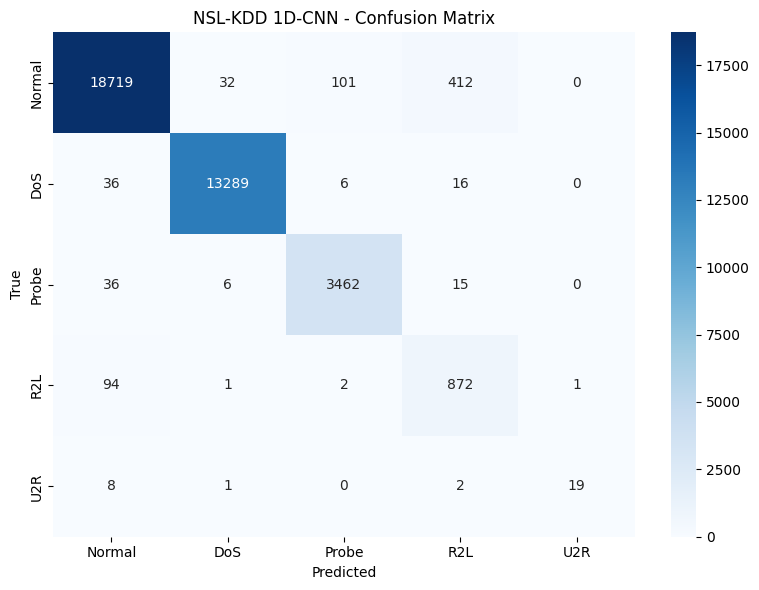

UNSW-NB15 1D-CNN
Accuracy              : 0.8087
Precision Macro       : 0.7277
Precision Weighted    : 0.7938
Recall Macro          : 0.6921
Recall Weighted       : 0.8087
F1 Macro              : 0.6716
F1 Weighted           : 0.7812

Classification report:
              precision    recall  f1-score   support

      Normal     0.8931    0.8645    0.8785     12500
     Generic     0.9949    0.9738    0.9842     12500
    Exploits     0.6686    0.9246    0.7760     11131
         DoS     0.4367    0.0355    0.0656      4088
     Fuzzers     0.6453    0.6622    0.6536      6062

    accuracy                         0.8087     46281
   macro avg     0.7277    0.6921    0.6716     46281
weighted avg     0.7938    0.8087    0.7812     46281



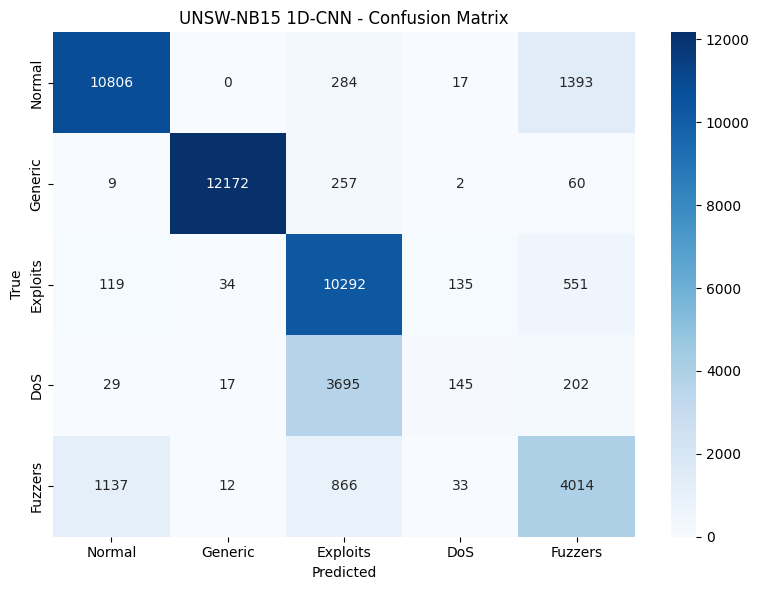

In [18]:
# ============================================================
# Evaluation function
# ============================================================

def evaluate_model(model, X_test, y_test, class_names, dataset_name):
    probabilities = model.predict(X_test, verbose=0)
    y_pred = np.argmax(probabilities, axis=1)

    metrics = {
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision Macro": precision_score(
            y_test, y_pred, average="macro", zero_division=0
        ),
        "Precision Weighted": precision_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "Recall Macro": recall_score(
            y_test, y_pred, average="macro", zero_division=0
        ),
        "Recall Weighted": recall_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "F1 Macro": f1_score(
            y_test, y_pred, average="macro", zero_division=0
        ),
        "F1 Weighted": f1_score(
            y_test, y_pred, average="weighted", zero_division=0
        )
    }

    print("=" * 70)
    print(dataset_name)
    print("=" * 70)

    for key, value in metrics.items():
        if key != "Dataset":
            print(f"{key:22s}: {value:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=np.arange(len(class_names))
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{dataset_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    metrics["y_pred"] = y_pred
    metrics["probabilities"] = probabilities
    metrics["confusion_matrix"] = cm

    return metrics

nsl_results = evaluate_model(
    nsl_model,
    X_nsl_test,
    y_nsl_test,
    nsl_class_names,
    "NSL-KDD 1D-CNN"
)

unsw_results = evaluate_model(
    unsw_model,
    X_unsw_test,
    y_unsw_test,
    unsw_class_names,
    "UNSW-NB15 1D-CNN"
)


In [19]:
# ============================================================
# Metrics summary
# ============================================================

results_summary = pd.DataFrame([
    {k: v for k, v in nsl_results.items()
     if k not in ["y_pred", "probabilities", "confusion_matrix"]},
    {k: v for k, v in unsw_results.items()
     if k not in ["y_pred", "probabilities", "confusion_matrix"]}
])

display(results_summary)


,Dataset,Accuracy,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1 Macro,F1 Weighted
0,NSL-KDD 1D-CNN,0.979289,0.913875,0.982383,0.896694,0.979289,0.895328,0.980287
1,UNSW-NB15 1D-CNN,0.808734,0.727713,0.793807,0.692098,0.808734,0.671600,0.781154


# 8. Training/validation curves

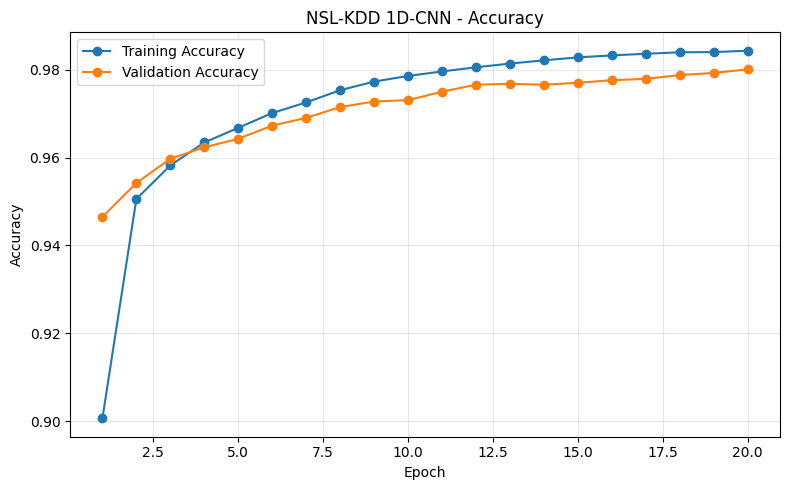

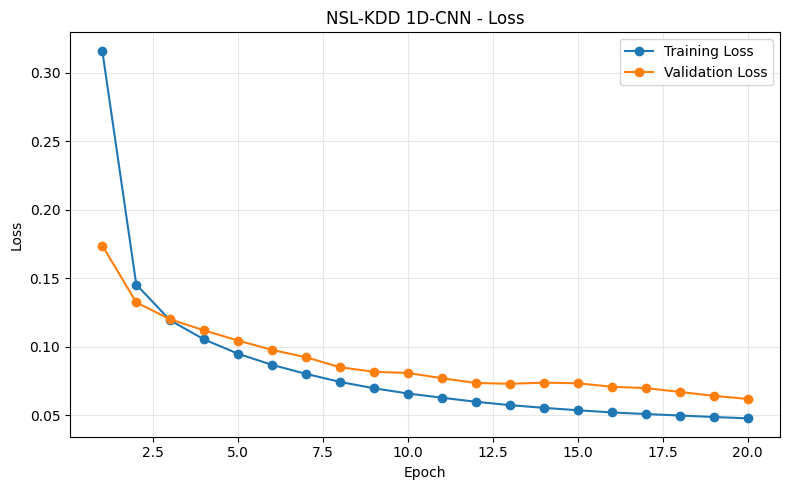

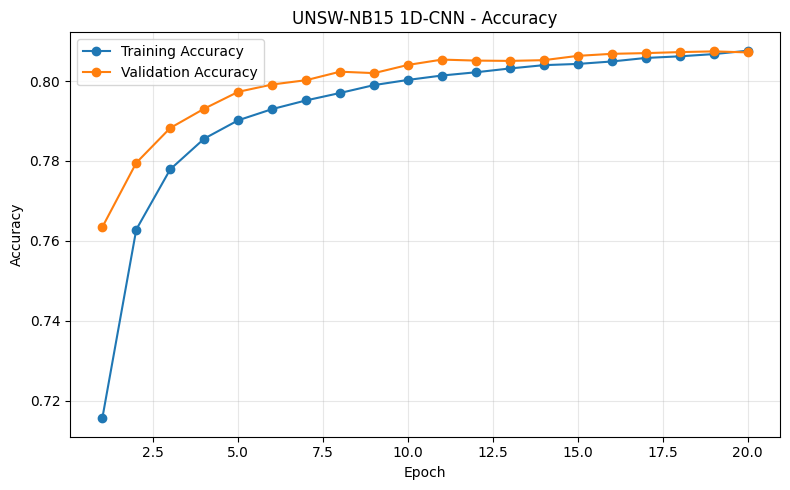

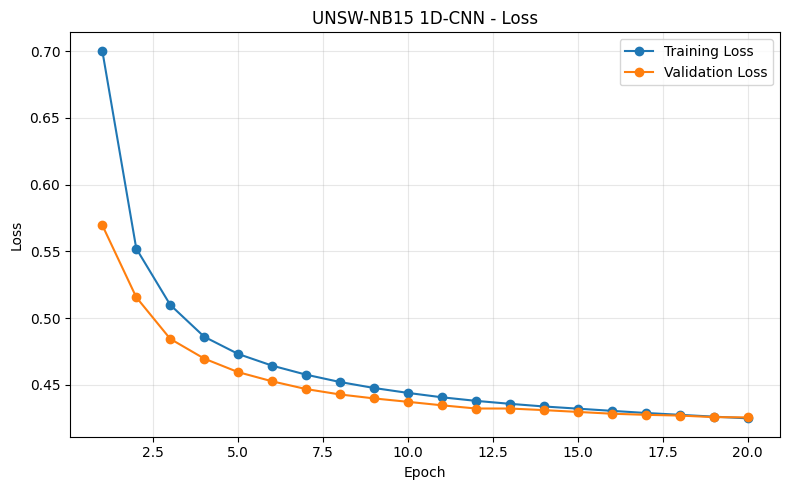

In [20]:
# ============================================================
# Plot training history
# ============================================================

def plot_training_history(history, dataset_name):
    h = history.history
    epochs = range(1, len(h["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, h["accuracy"], marker="o", label="Training Accuracy")
    plt.plot(epochs, h["val_accuracy"], marker="o", label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{dataset_name} - Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, h["loss"], marker="o", label="Training Loss")
    plt.plot(epochs, h["val_loss"], marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{dataset_name} - Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_training_history(nsl_history, "NSL-KDD 1D-CNN")
plot_training_history(unsw_history, "UNSW-NB15 1D-CNN")


# 9. Optional — SHAP explainability

The paper's explainability analysis primarily focuses on the DNN. This optional section applies SHAP to the trained 1D-CNN.

KernelExplainer is model-agnostic but can be slow. Start with a small background set and a small number of explained samples.


In [21]:
# ============================================================
# Optional SHAP installation
# ============================================================

# Uncomment if needed:
# %pip install -q shap


In [22]:
# ============================================================
# Optional SHAP explanation
# ============================================================

import shap

def run_shap_explanation(
    model,
    X_train,
    X_test,
    n_background=30,
    n_explain=10
):
    X_train_flat = X_train[:, :, 0]
    X_test_flat = X_test[:, :, 0]

    rng = np.random.default_rng(SEED)

    background_indices = rng.choice(
        len(X_train_flat),
        size=min(n_background, len(X_train_flat)),
        replace=False
    )

    background = X_train_flat[background_indices]
    explain_samples = X_test_flat[:min(n_explain, len(X_test_flat))]

    def predict_from_flat(X):
        return model.predict(
            X[..., np.newaxis],
            verbose=0
        )

    explainer = shap.KernelExplainer(
        predict_from_flat,
        background
    )

    shap_values = explainer.shap_values(
        explain_samples
    )

    return explainer, shap_values, explain_samples

print("SHAP version:", shap.__version__)


SHAP version: 0.52.0


## SHAP feature names

Because the preprocessing pipeline places numerical features first and encoded categorical features afterward, the feature names below are reconstructed in the same order.


In [23]:
# ============================================================
# Reconstruct final NSL-KDD feature names
# ============================================================

nsl_feature_names = [
    col
    for col in nsl_df.drop(
        columns=[
            NSL_LABEL_COLUMN,
            "target",
            "difficulty"
        ] + NSL_DROP_FEATURES,
        errors="ignore"
    ).columns
]

print("Number of feature names:", len(nsl_feature_names))
print(nsl_feature_names)


Number of feature names: 35
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_rerror_rate']


In [24]:
# ============================================================
# Run SHAP on NSL-KDD
# ============================================================

# This may be slow.
# Reduce n_background / n_explain if necessary.

nsl_shap_explainer, nsl_shap_values, nsl_shap_samples = (
    run_shap_explanation(
        nsl_model,
        X_nsl_train,
        X_nsl_test,
        n_background=30,
        n_explain=10
    )
)

print("SHAP calculation complete.")


  0%|          | 0/10 [00:00<?, ?it/s]

SHAP calculation complete.


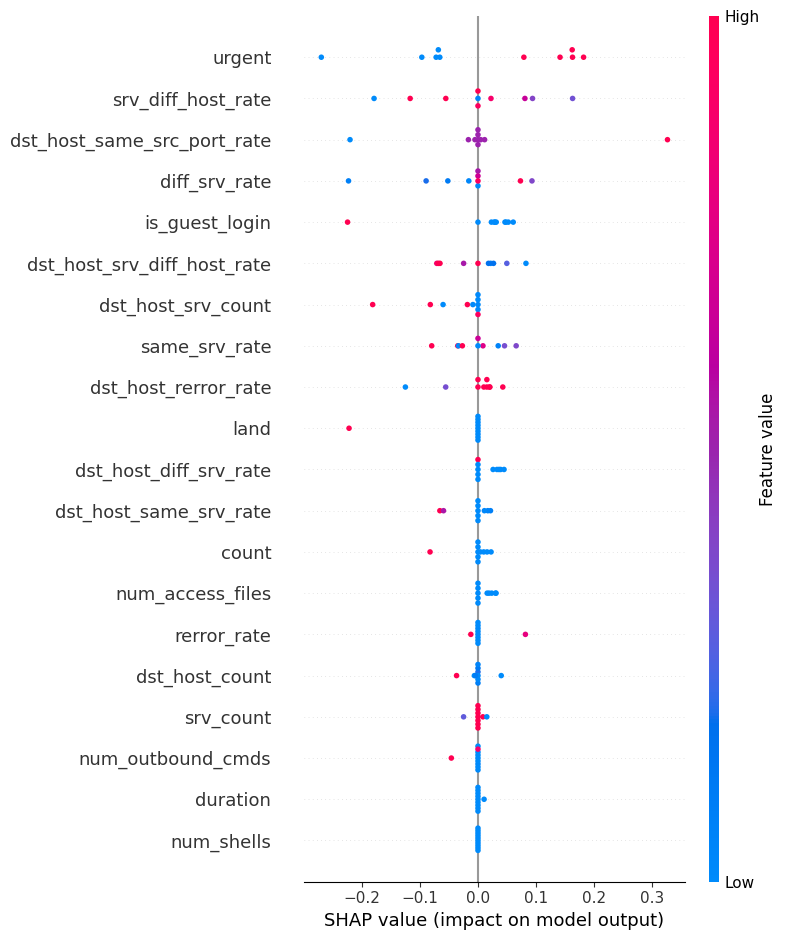

In [25]:
# ============================================================
# SHAP summary plot
# ============================================================

if isinstance(nsl_shap_values, list):
    shap_values_for_plot = nsl_shap_values[0]
else:
    shap_values_array = np.asarray(nsl_shap_values)

    if shap_values_array.ndim == 3:
        shap_values_for_plot = shap_values_array[:, :, 0]
    else:
        shap_values_for_plot = shap_values_array

shap.summary_plot(
    shap_values_for_plot,
    nsl_shap_samples,
    feature_names=nsl_feature_names,
    show=True
)


# Reproducibility checklist

Before comparing your results with Sharma et al. (2024), verify:

- [ ] KDDTrain+ + KDDTest+ used for NSL-KDD
- [ ] UNSW_NB15_training-set + UNSW_NB15_testing-set used
- [ ] Same dataset version
- [ ] Same five-class definitions
- [ ] Same paper-reported feature removals
- [ ] 60% train / 15% validation / 25% test
- [ ] Fixed random seed
- [ ] Min-Max scaling
- [ ] Kernel size = 3
- [ ] Pool size = 2
- [ ] ReLU
- [ ] 20 epochs
- [ ] Learning rate = 0.001
- [ ] Weight decay = 0.0001
- [ ] Sparse categorical cross-entropy
- [ ] 5-class Softmax output

## Critical caveat

The original paper does **not** disclose the complete 1D-CNN architecture. Therefore the 64 → 32 → 32 filter progression in this notebook is an explicit assumption and should be reported as such in a replication report.


## Dataset note

The notebook does not use the raw `UNSW-NB15_1` through
`UNSW-NB15_4` files. It uses the labeled training-set and
testing-set files shown in your dataset folder.

If your files have `.csv` or `.txt` extensions, the automatic
file detector handles either case.
